<a href="https://colab.research.google.com/github/malith001/ME421_Mechanical_Systems_Lab-A04/blob/main/Control/E20438_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><strong>ME421 - Mechanical Systems laboratory</strong></h1>
<h2><strong>PID control of a Twin Rotor System</strong></h2>
<h2><strong>E/20/438 - Wickramasekara D.S.P.</strong></h2>


---





## **Twin rotor system**


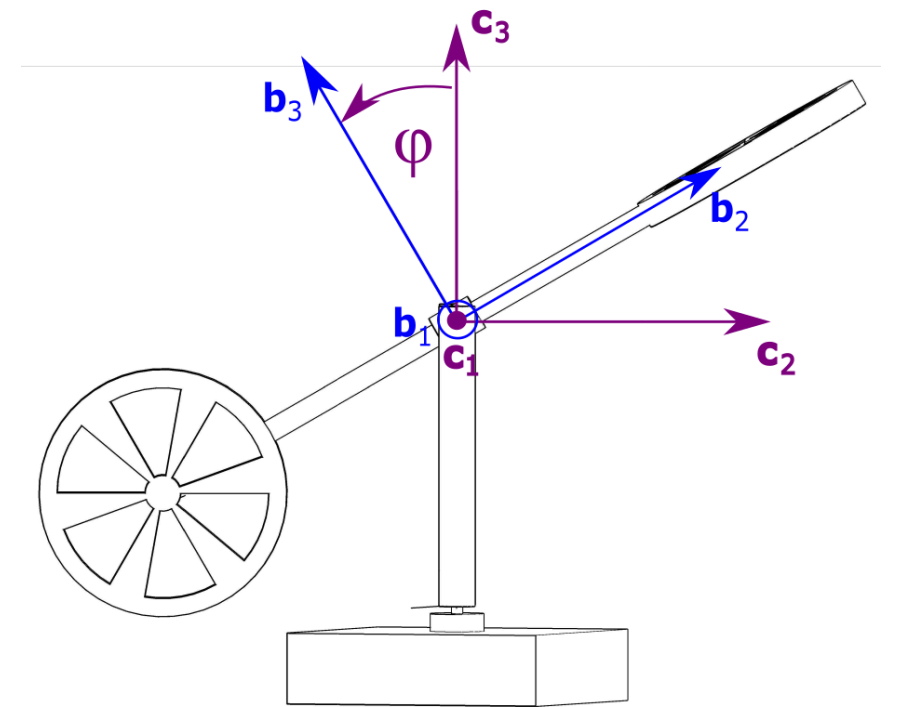



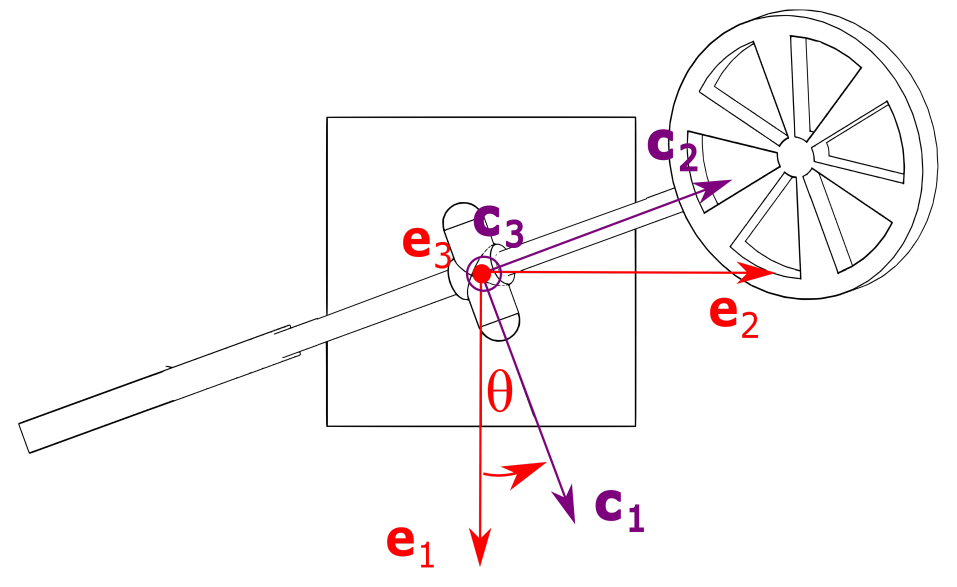

**Frame Definitions**

Let $\mathbf{e} = \{e_1, e_2, e_3\}$ denote the **Earth-fixed inertial frame**, which is stationary and used as the reference frame. The origin of this frame is located at the pivot point of the system.

Let $\mathbf{c} = \{c_1, c_2, c_3\}$ be an **intermediate orthonormal frame** attached to the vertical support structure. This frame rotates about the vertical axis $e_3$, representing the **yaw** motion of the system. Thus:
$$\mathbf{c} = \mathbf{e} R_3(\theta)$$
where $\theta$ is the yaw angle and:
$$R_3(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{bmatrix}$$

Let $\mathbf{b} = \{b_1, b_2, b_3\}$ be the **body-fixed frame** attached to the twin rotor beam. The origin coincides with that of frame $\mathbf{c}$, and the axis $b_1 \equiv c_1$ is aligned with the pivot axis. The frame $\mathbf{b}$ rotates relative to $\mathbf{c}$ about this axis, representing the **pitch** motion of the beam. Hence:
$$\mathbf{b} = \mathbf{c} R_1(\phi)$$
where $\phi$ is the pitch angle and:
$$R_1(\phi)=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi & -\sin\phi\\
0 & \sin\phi & \cos\phi
\end{bmatrix}$$

By combining the above transformations, the orientation of the body frame with respect to the inertial frame is given by:
$$\mathbf{b} = \mathbf{e} R_3(\theta)R_1(\phi) = \mathbf{e}R$$
where the total rotation matrix $R$ is:
$$R = R_3(\theta)R_1(\phi)$$

**Physical Interpretation**
* $\theta$: rotation about the fixed vertical axis $e_3$ (**yaw motion**)
* $\phi$: rotation about the moving axis $b_1 \equiv c_1$ (**pitch motion**)
* **Frame $\mathbf{c}$**: captures yaw motion.
* **Frame $\mathbf{b}$**: captures full body orientation (yaw + pitch).

## **Space of $R$ & Lie groups**

**space of $R$**

The matrix $R$ is a rotation matrix, so it belongs to the group:

$$SO(3) = \{R \in \mathbb{R}^{3\times 3} \mid R^TR=I, \det(R)=1\}$$

This is the **special orthogonal group** in 3D. The orientation is built from sequential rotations, and the rigid-body kinematics are written using $R$ and $\dot{R} = \hat{\omega}R$.

**Why $SO(3)$**

We use $SO(3)$ because the attitude of a rigid body is not a vector in $\mathbb{R}^n$. It is a rotation, and a valid rotation must preserve:
* Lengths
* Angles
* Orthogonality of axes

A matrix in $SO(3)$ does exactly that. It represents a pure 3D rotation with no stretching and no reflection. Therefore rigid-body rotations are treated as elements of $SO(3)$.

**Properties of $SO(3)$**

A matrix $R \in SO(3)$ satisfies:
$$R^TR = I, \quad \det(R) = 1$$
From this follow the important properties:
* **Identity exists:** $I \in SO(3)$
* **Inverse exists:** $R^{-1} = R^T$
* **Closure under multiplication:** if $R_1, R_2 \in SO(3)$, then $R_1R_2 \in SO(3)$
* **Non-commutative:** generally $R_1R_2 \neq R_2R_1$ ;order of rotations matters

**Lie group**

A Lie group is a set that is both:
1.  A **group** under multiplication, and
2.  A **smooth manifold**, meaning you can differentiate motions on it.

So $SO(3)$ is also a geometric object where you can multiply rotations and also study smooth time evolution.

**Lie algebra and the hat map**

Every Lie group has a corresponding Lie algebra. For $SO(3)$, the Lie algebra is $\mathfrak{so}(3)$, the space of $3 \times 3$ skew-symmetric matrices. Angular velocity belongs here through the **hat map**; converts a vector into a skew-symmetric matrix.
$$\omega = \begin{bmatrix} \omega_1 \\ \omega_2 \\ \omega_3 \end{bmatrix} \quad \longrightarrow \quad \hat{\omega} = \begin{bmatrix} 0 & -\omega_3 & \omega_2 \\ \omega_3 & 0 & -\omega_1 \\ -\omega_2 & \omega_1 & 0 \end{bmatrix}$$
The key identity is:
$$\hat{\omega}x = \omega \times x$$
This is why angular velocity is written in matrix form in rigid-body kinematics.

For a rigid body rotating in $SO(3)$, the orientation satisfies:
$$\dot{R} = \hat{\omega}R$$
This is the basic kinematic equation used in the twin rotor model. It tells you that the time change of orientation is determined by angular velocity.

## **Dynamics of the Twin Rotor System**

**Kinematics of the Twin Rotor System**
From the previous section, the orientation of the body frame relative to the inertial frame is:
$$R = R_3(\theta)R_1(\phi)$$

Substituting the rotation matrices:
$$R = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

Multiplying the matrices yields:
$$R = \begin{bmatrix} \cos\theta & -\cos\phi\sin\theta & \sin\phi\sin\theta \\ \sin\theta & \cos\phi\cos\theta & -\sin\phi\cos\theta \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

## 🔷 Time Derivative of the Rotation Matrix
To find the velocity of the orientation, we differentiate $R$:
$$\dot{R} = \dot{R}_3 R_1 + R_3 \dot{R}_1$$

Using rigid-body kinematics where $\dot{R}_i = R_i \hat{\Omega}_i$:
$$\dot{R} = R_3 \hat{\Omega}_3 R_1 + R_3 R_1 \hat{\Omega}_1$$

Factoring out $R = R_3 R_1$:
$$\dot{R} = R \left( R_1^T \hat{\Omega}_3 R_1 + \hat{\Omega}_1 \right)$$

Comparing this with the standard form $\dot{R} = R\hat{\Omega}$, we identify the body-frame angular velocity tensor:
$$\hat{\Omega} = R_1^T \hat{\Omega}_3 R_1 + \hat{\Omega}_1$$

## 🔷 Angular Velocity of the Twin Rotor System

### Step 1: Define individual angular velocities
*   **Rotation about $c_3 = e_3$ (Yaw):** $\Omega_3 = \dot{\theta} e_3$
*   **Rotation about $b_1$ (Pitch):** $\Omega_1 = \dot{\phi} b_1$

### Step 2: Express in the body frame
We must transform $\Omega_3$ into the body frame using $R_1^T$:
$$R_1^T e_3 = \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

Thus, the yaw contribution in the body frame is:
$$\Omega_3^{(body)} = \dot{\theta} \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

### Step 3: Combined Vector
$$\Omega = \Omega_1 + \Omega_3^{(body)} = \begin{bmatrix} \dot{\phi} \\ 0 \\ 0 \end{bmatrix} + \dot{\theta} \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

## 🔷 Final Angular Velocity Expression
$$\boxed{\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix}}$$

---

### 🔷 Physical Interpretation
*   $\dot{\phi}$: Direct rotation about the beam axis ($b_1$).
*   $\dot{\theta} \sin\phi$: Lateral component of yaw as the beam tilts.
*   $\dot{\theta} \cos\phi$: Vertical component of yaw.

> **Note:** This result shows how yaw motion couples into pitch dynamics. If required in the inertial frame (spatial angular velocity), it can be calculated as $\omega = R \Omega$.

### 🔷 Summary
The angular velocity of the twin rotor system is obtained by combining the contributions from the yaw motion about the inertial vertical axis and the pitch motion about the body-fixed axis. Expressing both components in the body frame yields the angular velocity vector $\Omega = [\dot{\phi}, \dot{\theta}\sin\phi, \dot{\theta}\cos\phi]^T$, which fully describes the rotational motion of the system.

---

Would you like me to proceed with deriving the **angular momentum** $\pi = I\Omega$ and the **torque equations** $\dot{\pi} = \tau$ for your dynamic model?